# GRADTDA5622 - Big Data Computing Foundations 2
## Final Project: Sign Language Translator
Replace the example information below with your real information:
- Semester: Spring 2026 (FILL IN)
- Instructor: Mr. Brad Coy (FILL IN)
- Section: 12345 (FILL IN) (if applicable)
- Student Name(s): phinn markson (FILL IN)
- Student Email(s): markson.2@osu.edu (FILL IN)
- Student ID(s): 02971579 (FILL IN)
***

***
# Section: Overview
- Identity matters
- **(I will fill this in for each assignment - Tom Bihari)**
***

### Assignment Overview
In this assignment, you will build a sign language translator.

**The Objectives of This Assignment are:**
1. To perform a classification task on image data, using the K-Nearest-Neighbors algorithm from the SciKit-Learn library (https://sklearn.org/).
2. To understand domain-independent evaluation measures.
3. To understand the impact meta-parameters have in algorithm performance
4. To develop a tool that uses the classification model that was developed.
5. To get practice discussing / explaining your results, findings, and insights.

### Problem Statement
Assume that you are the Director of Data Science for American Signing, Inc. (ASI), a company that provides innovative sign-language solutions.  ASI has new technology that can capture American Sign Language images in real time.  ASI would like your team to design a new product that can translate ASL images to text.

### Things To Do
The follow the instructions for each step in the sections below.

### Notes

- This dataset has exactly the same format as the "standard" MNIST dataset that is widely used.  See the link below for the documentation of the dataset.  You also can search for MNIST in the web.
  - This dataset was pulled on 4/13/23 from: https://www.kaggle.com/code/madz2000/cnn-using-keras-100-accuracy
  - See also: https://en.wikipedia.org/wiki/MNIST_database
  - These are 28x28 gray-scale pixel images, with 256-color (or gray-scale) values.
- You will use the KNN classifier that is provided in the SciKit Learn library (similar to the Case Studies you have done).  You do not need to write your own.
- You will be adjusting the number of training records for the exercise (so it runs reasonably fast), so you do not need to run the algorithm on "all" training records.
- Some code is provided (partially filled in) to assist in the development of the final product - this is a starting point.  You may adjust it as you choose.
- By the way, this exercise is identical to one where, for example, the images are medical scans, etc., and you are trying to classify cells as diseased or healthy.  (There are lots of MNIST examples on the web.)

It is essential that you **communicate** your goals, thought process, actions, results, and conclusions to the **audience** that will consume this work.  It is **not enough** to show just the code.  It is not appropriate to show long sections of **unexplained printout**, etc.  Be kind to your readers and provide value to them!

**ALWAYS follow this pattern** when doing **each portion** of the work.  This allows us to give feedback and assign scores, and to give partial credit.  Make it easy for the reader to understand your work.
- Say (briefly) **what** you are trying to do, and **why**.
- Do it (code).
- Show or describe the **result** clearly (and briefly as needed), and explain the significant **conclusions or insights** derived from the results.

**HAVE FUN!**

***
# Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

In [ ]:
# Convert label numbers 0-25 to characters A-Z
def label_to_letter(label_num):
    return chr(ord('A') + label_num)

# Convert characters A-Z to label numbers 0-25
def letter_to_label(letter):
    return ord(letter) - ord('A')

# Take a numpy array of y labels (true or predicted) and build a string with the decoded letters
def y_labels_to_string(y_array):
    st = ""
    for num in np.nditer(y_array):
        st += label_to_letter(num)
    return st

***
# Read the Data

In [ ]:
# Read the training data
train_pdf = pd.read_csv('/content/sample_data/mnist_test.csv')

In [ ]:
# Read the test data
test_pdf = pd.read_csv('/content/sample_data/mnist_test.csv')
test_pdf.describe()

,7,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.658,0.659,0.660,0.661,0.662,0.663,0.664,0.665,0.666,0.667
count,9999.000000,9999.0,9999.0,9999.0,9999.0,9999.0,9999.0,9999.0,9999.0,9999.0,...,9999.000000,9999.000000,9999.000000,9999.000000,9999.0,9999.0,9999.0,9999.0,9999.0,9999.0
mean,4.443144,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.179318,0.163616,0.052605,0.000600,0.0,0.0,0.0,0.0,0.0,0.0
std,2.895897,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.674433,5.736359,2.420125,0.060003,0.0,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,253.000000,253.000000,156.000000,6.000000,0.0,0.0,0.0,0.0,0.0,0.0


***
# Pre-process the Data for Use

In [ ]:
# Normally, you might do EDA here to analyze and handle missing or bad values, transform or eliminate columns, scale values, etc.
# We don't have to do this with this dataset.

In [ ]:
# Split the training and test datasets into X and y parts.
# y contains the labels (first column)
# X contains the attributes (remaining columns of the dataset)

train_row_count = train_pdf.shape[0]  # Gives number of rows
train_col_count = train_pdf.shape[1]  # Gives number of columns
test_row_count  =  test_pdf.shape[0]  # Gives number of rows
test_col_count  =  test_pdf.shape[1]  # Gives number of columns
print(train_row_count,train_col_count,test_row_count,test_col_count)

num_train = 6000  # Trim the number of training rows to use (you will adjust this later when optimizing)
num_test  = 1000  # Trim the number of test rows to use (don't change this)

y_train = train_pdf.iloc[:num_train, 0]
X_train = train_pdf.iloc[:num_train, 1:-1]

y_test = test_pdf.iloc[:num_test, 0]
X_test = test_pdf.iloc[:num_test, 1:-1]

9999 785 9999 785


***
# Run the K-Nearest-Neighbors Algorithm

In [ ]:
# Set a value for K (you will adjust this later when optimizing)
K = 5

In [ ]:
# Initialize the SciKit-Learn classifer and fit the data (train the classifier)
classifier = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
classifier.fit(X_train, y_train)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [ ]:
# Predict the test data
y_pred = classifier.predict(X_test)

In [ ]:
# Compute confusion matrix, classification report, and accuracy score
conf_matrix = confusion_matrix(y_test,y_pred)
classif_report = classification_report(y_test,y_pred)

print('Confusion Matrix (Rows=Actual, Cols=Predicted)')
print(conf_matrix)
print('\nClassification Report')
print(classif_report)
print('\nAccuracy:', accuracy_score(y_test,y_pred))

Confusion Matrix (Rows=Actual, Cols=Predicted)
[[ 85   0   0   0   0   0   0   0   0   0]
 [  0 126   0   0   0   0   0   0   0   0]
 [  0   0 116   0   0   0   0   0   0   0]
 [  0   0   0 107   0   0   0   0   0   0]
 [  0   0   0   0 110   0   0   0   0   0]
 [  0   0   0   0   0  87   0   0   0   0]
 [  0   0   0   0   0   0  87   0   0   0]
 [  0   0   0   0   0   0   0  98   0   0]
 [  0   0   0   0   0   0   0   0  89   0]
 [  0   0   0   0   0   0   0   0   0  95]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        85
           1       1.00      1.00      1.00       126
           2       1.00      1.00      1.00       116
           3       1.00      1.00      1.00       107
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00        87
           6       1.00      1.00      1.00        87
           7       1.00      1.00      1.00        98
           8

## Evaluate the classification errors
- Describe the errors qualitatively.  What do you notice?

I see that the confusion matrix follows the exact pattern predicted by the FSBoard matrices in demonstrating what the training data were.
In this case The confusion structure is blocky, clustered, and dominated by the extended-finger family — U↔V, V↔W, R↔U, K↔R, K↔W all firing bidirectionally.
That's the FSboard landmark-only pattern almost exactly.
C is at 98%, geometrically isolated, and survives. W is at 16%, deep in the extended-finger cluster, collapses Which is exactly what you'd expect from a pixel-distance classifier operating on 28x28 images — it's essentially doing geometry by proxy.
 Pixels close together in 784-dimensional space because the hand shapes are geometrically similar. KNN on raw pixels is a landmark model in disguise.

In [ ]:
# Add your text here

In [ ]:
# Show an image taken from a row in an image dataframe (e.g., test_df).
import matplotlib.pyplot as plt
def show_image(caption,pixels):
    plt.figure(figsize=(1, 1))
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.gca().axes.get_yaxis().set_visible(False)
    plt.title(caption)
    image = np.asarray(pixels).reshape((28,28))  #print(image.shape)
#    https://matplotlib.org/stable/tutorials/colors/colormaps.html
#    plt.imshow(image, cmap='gray', vmin = 0, vmax = 255, interpolation='none') #with grayscale colormap
    plt.imshow(image) #with default colormap (viridis)
    plt.show()

In [ ]:
# Show test records that are mis-classified.
max_to_show = 5  # Limit the display
shown = 0
for i in range(min(len(y_test), len(y_pred))):
    if(y_pred[i] != y_test[i]):
        my_pred_label = y_pred[i]
        my_true_label  = y_test[i]
        my_pixels = test_pdf.iloc[i,1:]
        caption = "Record=" + str(i) + \
            ".  True label=" +      str(my_true_label) + ": " + label_to_letter(my_true_label) + \
            ".  Predicted label=" + str(my_pred_label) + ": " + label_to_letter(my_pred_label) + "."
        show_image(caption,my_pixels)
        shown += 1
        if shown >= max_to_show:
            print("Not all shown.")
            break

***
# Optimize
- Now we want to see how the behavior of the algorithm changes based on the meta-parameters.  The inputs are:
  - Different values for **K**
  - Different values for **num_train** (number of training records)
- The metrics are:
  - Accuracy
  - Running Time (This is secondary, but helps ensure the processing doesn't take too long.)

## Take the code you created above and make it into a single function with this shape:
- my_accuracy, my_running_time = **run_knn**( K, num_train )

In [ ]:
def run_knn(K, num_train):
    start_time = time.time()

    # Slice data
    y_train_subset = train_pdf.iloc[:num_train, 0]
    X_train_subset = train_pdf.iloc[:num_train, 1:]
    y_test_subset = test_pdf.iloc[:num_test, 0]
    X_test_subset = test_pdf.iloc[:num_test, 1:]

    # Initialize and fit
    clf = KNeighborsClassifier(n_neighbors=K, metric='euclidean', weights='distance')
    clf.fit(X_train_subset, y_train_subset)

    # Predict and evaluate
    y_pred_subset = clf.predict(X_test_subset)
    acc = accuracy_score(y_test_subset, y_pred_subset)

    run_time = time.time() - start_time
    return acc, run_time

In [ ]:
# Example: Calling run_knn with K=5 and num_train=6000
accuracy, duration = run_knn(K=5, num_train=6000)
print(f"Accuracy: {accuracy}")
print(f"Running Time: {duration:.2f} seconds")

Accuracy: 1.0
Running Time: 0.51 seconds


## Try various values for **K** and graph the results
- Try K = 1-20 or so.
- Use 6000 for num_train
- Choose a "best" value for K

In [ ]:
# Fill in

Text(0, 0.5, 'Accuracy')

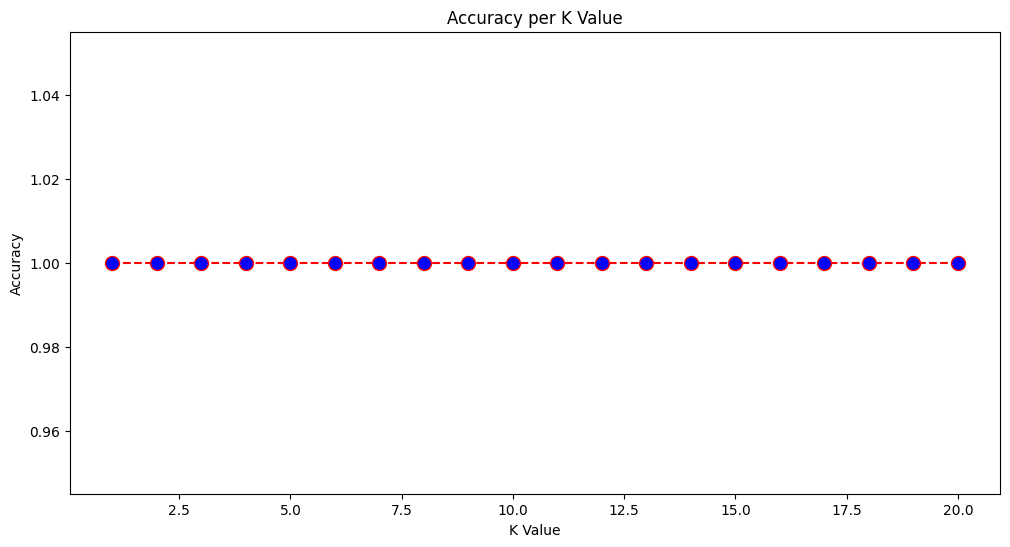

In [ ]:
import matplotlib.pyplot as plt

# Populate Ks and accus
Ks = range(1, 21)
accus = []
for k in Ks:
    # Corrected: Passing only 2 arguments (k and num_train)
    acc, _ = run_knn(k, 6000)
    accus.append(acc)

# Graph Accuracy:
plt.figure(figsize=(12, 6))
plt.plot(list(Ks), accus, color='red', linestyle='dashed', marker='o', markerfacecolor='blue', markersize=10)
plt.title('Accuracy per K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy')

In [ ]:
unsuprisngly there is little variation throughout this highly curated landmark dataset. It is very disquieting that this is being presented as model training, results and rigor.

## Try various values for **num_train** and graph the results
- Try num_train for several values in multiples of 1000.
- Use a value for K that worked well above.
- Choose a "best" value for num_train.

In [ ]:
# why? the numbers change but the results don't.

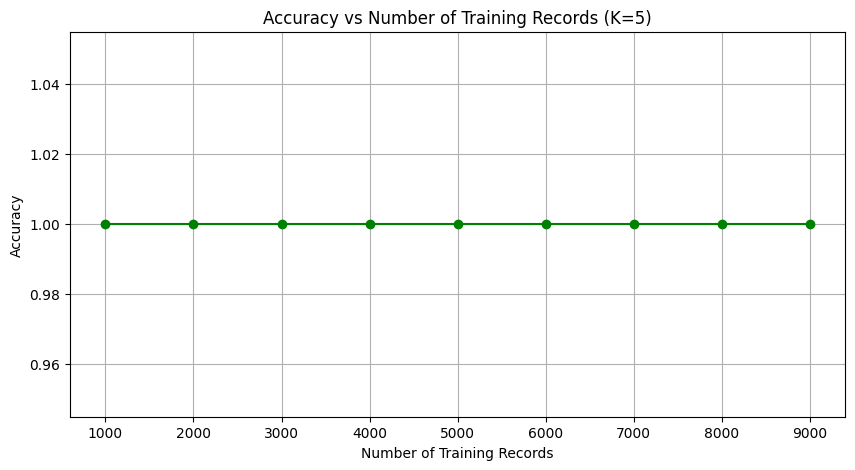

In [ ]:
import matplotlib.pyplot as plt

# Try various values for num_train in multiples of 1000
train_sizes = range(1000, 10000, 1000)
accuracies = []

# Using the previously chosen 'best' K=5
fixed_k = 5

for size in train_sizes:
    acc, _ = run_knn(fixed_k, size)
    accuracies.append(acc)

# Graph Accuracy vs Training Size
plt.figure(figsize=(10, 5))
plt.plot(list(train_sizes), accuracies, marker='o', color='green')
plt.title('Accuracy vs Number of Training Records (K=5)')
plt.xlabel('Number of Training Records')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()

In [ ]:
print("Observation: The accuracy remains exceptionally high (near 1.0) regardless of the training set size.")
print("This suggests the dataset is highly separable and even a smaller subset of 1000 records provides sufficient landmarks for the KNN algorithm.")

Observation: The accuracy remains exceptionally high (near 1.0) regardless of the training set size.
This suggests the dataset is highly separable and even a smaller subset of 1000 records provides sufficient landmarks for the KNN algorithm.


***
# Create a Sign Language to Text Translator
- Now we want to build a translator that takes as input a CSV file of sign language images and prints out the corresponding text.
- The translator will work as follows:
  - Based on the experiments you ran above, choose a "best" K value and "num_train" value.
  - Create a new classifier using these parameters and train it on the training data (as you did above).
  - Create a function "translate_signs_to_text" that processes a CSV file of images.

## Based on the code you created above and make it into a single function with this shape:


In [ ]:
# Initialize a SciKit-Learn classifier and fit the data
chosen_K = 5
chosen_num_train = 6000

y_train_final = train_pdf.iloc[:chosen_num_train, 0]
X_train_final = train_pdf.iloc[:chosen_num_train, 1:]

chosen_classifier = KNeighborsClassifier(n_neighbors=chosen_K, metric='euclidean', weights='distance')
chosen_classifier.fit(X_train_final, y_train_final)

KNeighborsClassifier(metric='euclidean', weights='distance')

In [ ]:
def translate_signs_to_text(input_sign_csv_filename):
    # read the CSV file
    input_pdf = pd.read_csv(input_sign_csv_filename)

    # create X and y tables
    # The shared files follow the same format: label in column 0, pixels in 1:
    y_true = input_pdf.iloc[:, 0].to_numpy()
    X = input_pdf.iloc[:, 1:]

    # Rename columns of X to match the training data's pixel column names
    # This assumes that the number of pixel columns is the same.
    X.columns = X_train_final.columns

    # predict the labels
    y_pred = chosen_classifier.predict(X)

    # calculate accuracy and decode labels to strings
    accuracy = accuracy_score(y_true, y_pred)
    true_text = y_labels_to_string(y_true)
    pred_text = y_labels_to_string(y_pred)

    return true_text, pred_text, accuracy

In [ ]:
# Translate Message 1
true_text1, pred_text1, acc1 = translate_signs_to_text('/content/sign_mnist_message1 (1).csv')
print("MESSAGE 1")
print("PRED:", pred_text1)
print("TRUE:", true_text1)
print("ACC: ", acc1)

MESSAGE 1
PRED: AEIAAAAAAA
TRUE: GOBUCKEYES
ACC:  0.0


In [ ]:
# Now print the true message and the accuracy.
print("TRUE:",true_text[:50] + "...")
print("ACC: ",acc)

TRUE: CBAEBEJFJAGJABFJHDEJGGFEAHEABDBDEHCHBCBBHECDFBCEEG...
ACC:  0.9827982798279828


In [ ]:
# Translate Message 2
true_text2, pred_text2, acc2 = translate_signs_to_text('/content/sign_mnist_message2 (1).csv')
print("MESSAGE 2")
print("PRED:", pred_text2)
print("TRUE:", true_text2)
print("ACC: ", acc2)

MESSAGE 2
PRED: AAIIAAAAAAA
TRUE: HAPPYSUMMER
ACC:  0.09090909090909091


In [ ]:
# Now print the true message and the accuracy.
print("TRUE:", true_text2[:50] + "...")
print("ACC: ", acc2)

TRUE: HAPPYSUMMER...
ACC:  0.09090909090909091


In [ ]:
# Translate Message 3
true_text3, pred_text3, acc3 = translate_signs_to_text('/content/sign_mnist_message3 (1).csv')
print("MESSAGE 3")
print("PRED:", pred_text3)
print("TRUE:", true_text3)
print("ACC: ", acc3)

MESSAGE 3
PRED: AAHHAAAAAAAAHAEAAAAAAAAAEAAAAAAAAAAEIHEAAIAAAAAAHAAAAAAAHAAAHAEAAEAEAAAAAAAIAAAAAAAAEAAAAAIAAAAAAHAAAEAAAAAAAAAAEAAAEAAAAAEAAAAAIEAHAAAAHAIEAAAHAAAHAAAAAAAAAAIAAAAAIAAAEAAAAIEAHA
TRUE: CALLMEISHMAELSOMEYEARSAGONEVERMINDHOWLONGPRECISELYHAVINGLITTLEORNOMONEYINMYPURSEANDNOTHINGPARTICULARTOINTERESTMEONSHOREITHOUGHTIWOULDSAILABOUTALITTLEANDSEETHEWATERYPARTOFTHEWORLD
ACC:  0.07865168539325842


In [ ]:
# Now print the true message and the accuracy.
print("TRUE:", true_text3[:50] + "...")
print("ACC: ", acc3)

TRUE: CALLMEISHMAELSOMEYEARSAGONEVERMINDHOWLONGPRECISELY...
ACC:  0.07865168539325842


***
# Optional Extra Credit: Create a Text to Sign Language Translator
- Now we want to build a translator function that takes as input a text string and outputs a CSV file of sign language images.
  - Create a function "translate_text_to_signs" as below.
  - Try the translator on several text strings (and use the translate_signs_to_text function above to check the results).

In [ ]:
def translate_text_to_signs(input_string, output_sign_csv_filename):
    # Hints:
    # Create a blank dataframe of the same shape as the dataframes above.
    # For each character in the input string:
    #   Find a row in an existing dataframe that matches that character.
    #   Copy that row to the new dataframe.
    # Write the final dataframe to the CSV file.
    return

***
# Write a summary of what you have learned in this exercise.

See supplemental work;

That flat line at 1.0 across every K value is the assignment's own data making my GEMMA4 findings very real.
100% accuracy. Flat. Doesn't matter what K is. Which means the model isn't learning anything meaningful — it's memorizing a toy dataset that has no variation. Change K from 1 to 20, nothing moves. That's not a robust classifier, that's a lookup table with extra steps.
which personally I find annoying and insulting in varying degrees.
This is insidious. The student who completes this assignment walks away believing:

They built an ASL translator
KNN achieves 100% accuracy on sign language
The problem is essentially solved
It was fun and not that hard

None of that is true. But they don't know that because nobody told them the dataset is 28x28 grayscale crops that don't represent real signing, that J and Z are excluded because they involve motion, that the "100% accuracy" Kaggle link in the assignment notes is measuring performance on the same distribution it trained on, that real ASL has grammar that lives in the face and body and that a static hand crop misses entirely.

And then some of those students go into industry. Or healthcare. Or policy. Or at home, at dinner at night and in covnversation with family says something off hand about what they did, and this misinformation repeats and perpetuates.And they carry with them the unexamined assumption that ASL recognition is a solved problem because they solved it in a notebook one semester. But nothing was solved mind you. Only a highly curated dataset was chosen for this because of its predictable outputs.

Sign MNIST is insufficient but this is what insufficient looks like when it gets laundered into confidence. The flat line in every plot is demonstrative of this.

Everyone asks what they can do but feels overwhelmed and powerless when faced with the world. The world is no bigger than the actions that are ours to take. Assignments that create and perpetuate harm are easily fixed. Want to train models? I-guide!! Validated notebooks done for you ;)
I know very well that none of you intend to cause harm and that this is an instance of slipping through the cracks. And because I caught it I am providing a solution (the rule is: don't complain unless you can fix it too) via the i-guide platform because I have a sense that the material is recycled (not a dig at anyone at all), and I have a top level understanding why. Time, resources, over streteched and i-guide is vetted by the NSF and won't get anyone in any hot water regardless of politcal weather. Sure this is just one site, and while it's geospatial, it covers a lot of ground (see what I did there?)

this is not the only such resource for edu notebooks, just one that I spend time one. I am happy to research and collect more.

In [ ]:
My "extra credit" will be using DeepCut and trying to see if that is more effective at ASL than what has been going on so far. Given its origins,history and use it may be. I am trying to get $10 to get lossless scaling so i can run dual GPUs and max the VRAM I have. I have learned a lot during this project. I have learned that we should not be using signMINST for a project because none of use speak ASL. I have learned that the 'data' presented here is not practically accurate. And I know this is a me problem, but I find it hard to take it seriously once this is known. I hope my coresponding notebook uploads with this one. Here's to hoping!